# BRFSS 2024 Colorectal Cancer Screening: Modelling

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Input:** `crc_analytic_dataset.csv` (Data Preparation output — 227,647 eligible respondents)

This notebook implements proposal steps **(c) Data Processing**, **(d) Modelling** and part of
**(e) Evaluation**, and responds to the professor's comments on calibration, internal/external
validation and subgroup equity reporting.

## Scope of this notebook

- Primary binary outcome (`crc_noncompliant`), which the proposal commits to as the modelling
  target, using the M1 (demographic) / M2 (+access) / M3 (+health) ablation structure and the
  logistic-regression-baseline-vs-gradient-boosting comparison already piloted in Annex C.
- Redundancy check across the 17 predictors (proposal step c), which the proposal commits to but
  which no notebook has done yet.
- A single train / calibration / test split used consistently throughout, sized to also support
  the professor's calibration request.
- Geographic (leave-states-out) validation as the internal/external validation the professor asked
  about, since a genuine Singapore external validation set isn't available.
- A risk-decile table and subgroup (insurance / income / race / sex / age) performance breakdown,
  responding directly to the professor's calibration and equity comments.
- A sensitivity analysis testing KNN imputation against the primary "Not reported" strategy for the
  two predictors where that choice is non-trivial (`income_group`, `bmi_category`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
if not ANALYTIC_PATH.exists():
    raise FileNotFoundError(
        f"{ANALYTIC_PATH} not found. Run '1 Data Preparation.ipynb' first."
    )

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={
        "respondent_id": "string",
        "state_fips": "string",
    },
    low_memory=False,
)
print("Loaded:", ANALYTIC_PATH)
print("Shape:", df.shape)
df.head()

Loaded: ..\data\processed\crc_analytic_dataset.csv
Shape: (227647, 27)


,respondent_id,source_row_id,state_fips,validation_group_state,age_exact,_CRCREC3,crc_noncompliant,crc_screening_status,noncompliance_type,age_group,sex,race_ethnicity,education_level,income_group,employment_status,marital_status,urban_rural,insurance_status,personal_doctor,cost_barrier,checkup_recency,general_health,diabetes_status,heart_disease,smoking_status,bmi_category,housing_tenure
0,01-2024000003,3,01,1,59,3,1,Never screened,Never screened,55-59,Male,"White only, non-Hispanic",Attended college or technical school,Not reported,Employed for wages,Member of an unmarried couple,Urban,Insured,No personal doctor,Yes,5 or more years,Very good,No diabetes,CHD or MI not reported,Current smoker - every day,Normal weight,Own
1,01-2024000005,5,01,1,47,3,1,Never screened,Never screened,45-49,Male,"White only, non-Hispanic",Attended college or technical school,"$15,000 to < $25,000",Unable to work,Never married,Urban,Insured,Has personal doctor,No,Within past year,Good,No diabetes,CHD or MI not reported,Never smoked,Normal weight,Own
2,01-2024000006,6,01,1,54,1,0,Up to date,Not applicable - compliant,50-54,Male,"White only, non-Hispanic",Graduated high school,"$100,000 to < $200,000",Employed for wages,Married,Urban,Insured,Has personal doctor,No,Within past year,Good,Diabetes,CHD or MI not reported,Never smoked,Obese,Rent
3,01-2024000007,7,01,1,71,1,0,Up to date,Not applicable - compliant,70-74,Female,"White only, non-Hispanic",Attended college or technical school,"$35,000 to < $50,000",Retired,Married,Rural,Insured,Has personal doctor,No,Within past year,Fair,No diabetes,CHD or MI reported,Never smoked,Obese,Own
4,01-2024000008,8,01,1,68,1,0,Up to date,Not applicable - compliant,65-69,Female,"White only, non-Hispanic",Attended college or technical school,Not reported,Retired,Married,Rural,Insured,Has personal doctor,No,Within past year,Poor,Diabetes,CHD or MI not reported,Never smoked,Obese,Own


## 1. Modelling targets

The primary target already exists from data preparation. We also prepare (but do not model here) the two-stage targets for a possible follow-up notebook, so both are defined from the same source column and can't drift out of sync.

In [2]:
assert df["crc_noncompliant"].isna().sum() == 0
assert set(df["crc_noncompliant"].unique()) == {0, 1}

# Two-stage targets, prepared for a follow-up notebook (not modelled here).
df["never_screened"] = (df["crc_screening_status"] == "Never screened").astype(int)

ever_screened_mask = df["crc_screening_status"].isin(["Up to date", "Overdue"])
df["overdue_given_screened"] = np.where(
    ever_screened_mask,
    (df["crc_screening_status"] == "Overdue").astype(int),
    np.nan,
)

print("Primary target rate (crc_noncompliant):", f"{df['crc_noncompliant'].mean():.4f}")
print("Never-screened rate (full cohort):     ", f"{df['never_screened'].mean():.4f}")
print(
    "Overdue rate (among ever-screened only):",
    f"{df.loc[ever_screened_mask, 'overdue_given_screened'].mean():.4f}",
)

assert df["never_screened"].sum() == 43_930
assert ever_screened_mask.sum() == 167_374 + 16_343
assert df.loc[ever_screened_mask, "overdue_given_screened"].sum() == 16_343

Primary target rate (crc_noncompliant): 0.2648
Never-screened rate (full cohort):      0.1930
Overdue rate (among ever-screened only): 0.0890


## 2. Predictor domains and encoding plan

Reuses the M1/M2/M3 domain structure from notebook 1. Predictors split into **ordinal** (natural order, encoded as a rank plus a separate not-reported flag so the missing category doesn't sit inside the ordinal scale) and **nominal** (one-hot for logistic regression; native categorical handling for gradient boosting). `bmi_category`, `smoking_status` and `checkup_recency` are treated as nominal even though their categories look ordered, because the EDA and the underlying clinical relationship (e.g. BMI's U-shaped risk) aren't necessarily monotonic -- forcing an ordinal scale there would assume a linear effect that may not hold.

In [3]:
demographic_features = ["age_group", "sex", "race_ethnicity", "education_level", "income_group",
                        "employment_status", "marital_status", "urban_rural"]
access_features = ["insurance_status", "personal_doctor", "cost_barrier", "checkup_recency"]
health_features = ["general_health", "diabetes_status", "heart_disease", "smoking_status", "bmi_category"]

M1_FEATURES = demographic_features
M2_FEATURES = M1_FEATURES + access_features
M3_FEATURES = M2_FEATURES + health_features

assert len(M1_FEATURES) == 8
assert len(M2_FEATURES) == 12
assert len(M3_FEATURES) == 17

ORDINAL_FEATURES = ["age_group", "income_group", "education_level", "general_health"]
NOMINAL_FEATURES = [f for f in M3_FEATURES if f not in ORDINAL_FEATURES]
assert len(ORDINAL_FEATURES) + len(NOMINAL_FEATURES) == 17

ORDINAL_CATEGORY_ORDER = {
    "age_group": ["45-49", "50-54", "55-59", "60-64", "65-69", "70-74",
                  "75 (source category 75-79)"],
    "income_group": ["Less than $15,000", "$15,000 to < $25,000", "$25,000 to < $35,000",
                      "$35,000 to < $50,000", "$50,000 to < $100,000", "$100,000 to < $200,000",
                      "$200,000 or more"],
    "education_level": ["Did not graduate high school", "Graduated high school",
                         "Attended college or technical school",
                         "Graduated college or technical school"],
    "general_health": ["Poor", "Fair", "Good", "Very good", "Excellent"],
}
for col, order in ORDINAL_CATEGORY_ORDER.items():
    observed = set(df[col].unique()) - {"Not reported"}
    assert observed == set(order), f"{col}: category order doesn't match observed values"

print("M1 (demographic):", M1_FEATURES)
print("M2 adds (access):", access_features)
print("M3 adds (health):", health_features)
print("Ordinal:", ORDINAL_FEATURES)
print("Nominal:", NOMINAL_FEATURES)

M1 (demographic): ['age_group', 'sex', 'race_ethnicity', 'education_level', 'income_group', 'employment_status', 'marital_status', 'urban_rural']
M2 adds (access): ['insurance_status', 'personal_doctor', 'cost_barrier', 'checkup_recency']
M3 adds (health): ['general_health', 'diabetes_status', 'heart_disease', 'smoking_status', 'bmi_category']
Ordinal: ['age_group', 'income_group', 'education_level', 'general_health']
Nominal: ['sex', 'race_ethnicity', 'employment_status', 'marital_status', 'urban_rural', 'insurance_status', 'personal_doctor', 'cost_barrier', 'checkup_recency', 'diabetes_status', 'heart_disease', 'smoking_status', 'bmi_category']


## 3. Train / calibration / test split

One split, used everywhere in this notebook, stratified on the primary target. A 60/20/20 three-way split (rather than the proposal's illustrative 80/20) because the professor's calibration request needs a dedicated calibration slice the model never trains on -- with N=227,647 there's no need for cross-validated calibration to preserve sample size. `respondent_id`, `validation_group_state` (geographic validation) and the equity subgroup columns are carried through the split untouched; none of them are ever used as model features.

In [4]:
from sklearn.model_selection import train_test_split

EQUITY_COLUMNS = ["insurance_status", "income_group", "race_ethnicity", "sex", "age_group"]
AUX_COLUMNS = ["respondent_id", "validation_group_state"] + EQUITY_COLUMNS

y = df["crc_noncompliant"]
X = df[M3_FEATURES].copy()
aux = df[AUX_COLUMNS].copy()

X_train, X_temp, y_train, y_temp, aux_train, aux_temp = train_test_split(
    X, y, aux, test_size=0.4, random_state=RANDOM_SEED, stratify=y
)
X_cal, X_test, y_cal, y_test, aux_cal, aux_test = train_test_split(
    X_temp, y_temp, aux_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

assert len(X_train) + len(X_cal) + len(X_test) == len(df)

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648


## 4. Predictor redundancy check (Cramer's V)

All 17 predictors are categorical, so pairwise association is measured with bias-corrected Cramer's V rather than Pearson correlation. Computed on the **training fold only** to avoid using test data for any modelling decision, even a feature-selection one.

In [5]:
from itertools import combinations
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    table = pd.crosstab(a, b)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.sum().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan

rows = []
for f1, f2 in combinations(M3_FEATURES, 2):
    rows.append((f1, f2, cramers_v(X_train[f1], X_train[f2])))
cramers_table = (
    pd.DataFrame(rows, columns=["Feature 1", "Feature 2", "Cramers_V"])
    .sort_values("Cramers_V", ascending=False)
    .reset_index(drop=True)
)
cramers_table.to_csv(MODEL_DIR / "predictor_redundancy_cramers_v.csv", index=False)
cramers_table.head(15)

,Feature 1,Feature 2,Cramers_V
0,personal_doctor,checkup_recency,0.333184
1,age_group,employment_status,0.250034
2,insurance_status,personal_doctor,0.237593
3,education_level,income_group,0.217844
4,income_group,employment_status,0.196966
5,insurance_status,checkup_recency,0.192060
6,insurance_status,cost_barrier,0.191843
7,sex,bmi_category,0.187774
8,employment_status,general_health,0.186684
9,general_health,heart_disease,0.181837


**Reading this table:** Cramer's V ranges 0 (independent) to 1 (perfectly redundant). The strongest association is `personal_doctor` x `checkup_recency` (~0.33) -- moderate, expected (having a doctor and going for check-ups are related access behaviours), but far below the level (roughly >0.7-0.8) that would indicate the two fields are measuring almost the same thing, which was the standard already applied to justify dropping "primary coverage source" in favour of `insurance_status` at the proposal stage. No pair here clears that bar, so all 17 predictors are retained -- nothing is redundant enough to drop automatically. Worth keeping the `personal_doctor` / `checkup_recency` pair in mind when interpreting logistic-regression coefficients individually, since their effects will partly overlap.

## 5. Preprocessing pipelines

Two different encodings, matched to what each model actually needs, both wrapped in `sklearn.Pipeline` so every encoder/scaler is fit on the training fold only and applied unchanged to calibration/test -- no leakage.

**Logistic regression:** ordinal fields become an integer rank plus a separate binary `not_reported` flag (a small custom transformer below -- `OrdinalRankWithMissingFlag`), so "Not reported" doesn't sit inside the ordinal scale as if it were a value. Nominal fields are one-hot encoded (`handle_unknown="ignore"`). Everything is standardised afterwards, since L2 regularisation penalises coefficients more fairly when features are on a common scale.

**Gradient boosting:** `HistGradientBoostingClassifier` supports categorical features natively -- every one of the 17 predictors is ordinal-encoded to integers purely as a storage format (order is irrelevant) and flagged as categorical via `categorical_features`, so the model does proper category-aware splits rather than assuming a numeric order. No one-hot needed for trees.

**Class imbalance:** both models use `sample_weight` computed via `compute_sample_weight("balanced", y_train)` rather than oversampling to 50/50 -- this corrects the training loss for the 26.5% positive rate without duplicating/synthesising rows or distorting the probabilities that later get calibrated.

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier


class OrdinalRankWithMissingFlag(BaseEstimator, TransformerMixin):
    """Maps each ordinal column to its rank (0..k-1) using an explicit, pre-defined category
    order, plus a companion 0/1 'not reported' flag. 'Not reported' is never given a rank of its
    own -- it would otherwise sit at an arbitrary point on the ordinal scale.

    The category order is supplied at construction time (derived from the codebook, not fit from
    data), so `fit` only needs to record the column order it was given.
    """

    def __init__(self, category_orders):
        self.category_orders = category_orders

    def fit(self, X, y=None):
        self.columns_ = list(X.columns) if hasattr(X, "columns") else list(self.category_orders)
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        out = {}
        for col in self.columns_:
            rank_map = {cat: rank for rank, cat in enumerate(self.category_orders[col])}
            ranks = X[col].map(rank_map)
            out[f"{col}__rank"] = ranks.fillna(-1).astype(float)
            out[f"{col}__not_reported"] = ranks.isna().astype(float)
        return pd.DataFrame(out, index=X.index).values

    def get_feature_names_out(self, input_features=None):
        names = []
        for col in self.columns_:
            names += [f"{col}__rank", f"{col}__not_reported"]
        return np.array(names)


def ordinal_subset(features):
    return [f for f in features if f in ORDINAL_FEATURES]


def nominal_subset(features):
    return [f for f in features if f in NOMINAL_FEATURES]


def build_logreg_pipeline(features):
    pre = ColumnTransformer([
        ("ordinal", OrdinalRankWithMissingFlag(
            {c: ORDINAL_CATEGORY_ORDER[c] for c in ordinal_subset(features)}
        ), ordinal_subset(features)),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_subset(features)),
    ])
    return Pipeline([
        ("preprocess", pre),
        ("scale", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])


def build_gb_pipeline(features):
    pre = ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), features),
    ])
    return Pipeline([
        ("preprocess", pre),
        ("model", HistGradientBoostingClassifier(
            categorical_features=[True] * len(features),
            random_state=RANDOM_SEED,
        )),
    ])


print("Pipelines defined: build_logreg_pipeline(features), build_gb_pipeline(features)")

Pipelines defined: build_logreg_pipeline(features), build_gb_pipeline(features)


## 6. M1 / M2 / M3 ablation

Fit each domain x model combination on the training fold, weighted for class imbalance, and evaluate once on the held-out test fold -- mirrors Annex C's own ablation table so the numbers below can be checked directly against the proposal's preliminary results.

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

w_train = compute_sample_weight("balanced", y_train)

ablation_rows = []
fitted_pipelines = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    for model_name, builder in [("logreg", build_logreg_pipeline), ("gb", build_gb_pipeline)]:
        pipe = builder(features)
        pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
        proba = pipe.predict_proba(X_test[features])[:, 1]
        pred = (proba >= 0.5).astype(int)
        ablation_rows.append({
            "Model": domain_name,
            "Estimator": model_name,
            "N predictors": len(features),
            "AUROC": roc_auc_score(y_test, proba),
            "AUPRC": average_precision_score(y_test, proba),
            "Sensitivity": recall_score(y_test, pred),
            "Accuracy": accuracy_score(y_test, pred),
        })
        fitted_pipelines[(domain_name, model_name)] = pipe

ablation_table = pd.DataFrame(ablation_rows)
ablation_table.to_csv(MODEL_DIR / "ablation_results.csv", index=False)
ablation_table.round(3)

,Model,Estimator,N predictors,AUROC,AUPRC,Sensitivity,Accuracy
0,M1,logreg,8,0.710,0.483,0.660,0.656
1,M1,gb,8,0.721,0.502,0.620,0.680
2,M2,logreg,12,0.753,0.581,0.642,0.712
3,M2,gb,12,0.763,0.594,0.638,0.727
4,M3,logreg,17,0.755,0.583,0.645,0.716
5,M3,gb,17,0.766,0.598,0.639,0.727


**Comparison with Annex C's preliminary gradient-boosting run:**

| | M1 | M2 | M3 |
|---|---|---|---|
| AUROC here (GB) | 0.721 | 0.763 | 0.766 |
| AUROC, Annex C | 0.724 | 0.768 | 0.770 |
| Sensitivity here (GB) | 0.620 | 0.638 | 0.639 |
| Sensitivity, Annex C | 0.256 | 0.344 | 0.349 |

AUROC lands within 0.003-0.005 of Annex C across all three domains -- close enough to confirm the
pipeline rebuild reproduces the same underlying signal. The small gap plausibly comes from a
smaller training fold here (60% vs. Annex C's presumed 80%, since this notebook also carves out a
calibration fold) and from class-weighted training, which trades a sliver of ranking performance
for the much larger sensitivity gain below -- not from any difference in the underlying data.

Sensitivity is 1.8-2.4x higher than Annex C's preliminary run at every domain (M3: 0.639 vs.
0.349) -- the direct, measurable payoff of `sample_weight`-based class weighting instead of
leaving the 26.5% imbalance untreated. Annex C's model was finding barely a third of non-compliant
respondents at a 0.5 threshold; this one finds close to two-thirds.

Access adds a clear increment over demographics alone (GB AUROC +0.042, 0.721 -> 0.763), matching
Annex C's own +0.044 finding almost exactly, and reconfirming the proposal's central claim that
access -- not demographic composition -- is the main modifiable signal for targeting. Health status
adds almost nothing further (+0.003, 0.763 -> 0.766 for GB; +0.002 for logistic regression),
matching Annex C's "health status added little further." Logistic regression trails gradient
boosting by only ~0.01 AUROC at M3 (0.755 vs. 0.766) while staying fully interpretable -- a
reasonable case for keeping it as the reported baseline alongside gradient boosting as the leading
model, per proposal step (d).

## 7. Geographic internal-external validation

The professor asked about internal/external validation; a genuine Singapore holdout isn't available (that's the whole transferability limitation the proposal already flags), so the closest available substitute is treating BRFSS states as separate populations and checking whether the model generalises across them --  a leave-states-out `GroupKFold` on `validation_group_state`, run only on the training fold so the test fold stays untouched for the headline numbers above. This focuses on the leading model (M3 gradient boosting), per proposal step (f)'s instruction to run further checks on the leading model rather than repeating everything six times. `_STATE`/`validation_group_state` is used only to define the folds -- never as a feature.

In [8]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
geo_rows = []
for fold, (tr_idx, va_idx) in enumerate(
    gkf.split(X_train[M3_FEATURES], y_train, groups=aux_train["validation_group_state"])
):
    Xtr, Xva = X_train[M3_FEATURES].iloc[tr_idx], X_train[M3_FEATURES].iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    w = compute_sample_weight("balanced", ytr)
    pipe = build_gb_pipeline(M3_FEATURES)
    pipe.fit(Xtr, ytr, model__sample_weight=w)
    proba = pipe.predict_proba(Xva)[:, 1]
    n_states_held_out = aux_train["validation_group_state"].iloc[va_idx].nunique()
    geo_rows.append({
        "Fold": fold,
        "States held out": n_states_held_out,
        "N": len(va_idx),
        "AUROC": roc_auc_score(yva, proba),
    })

geo_table = pd.DataFrame(geo_rows)
geo_table.to_csv(MODEL_DIR / "geographic_validation.csv", index=False)
print(geo_table.round(3))
print(
    f"\nMean AUROC across held-out state groups: {geo_table['AUROC'].mean():.3f} "
    f"(sd {geo_table['AUROC'].std():.3f})"
)
m3_gb_auroc = ablation_table.query("Model == 'M3' and Estimator == 'gb'")["AUROC"].values[0]
print(f"Held-out test-set AUROC for comparison: {m3_gb_auroc:.3f}")

   Fold  States held out      N  AUROC
0     0               10  27561  0.766
1     1               10  27331  0.774
2     2               11  27236  0.775
3     3               11  27268  0.755
4     4               11  27192  0.758

Mean AUROC across held-out state groups: 0.765 (sd 0.009)
Held-out test-set AUROC for comparison: 0.766


Fold AUROCs: 0.766, 0.774, 0.775, 0.755, 0.758 across the 5 state groups (10-11
states held out per fold) -- mean 0.765, sd 0.009. That's a tight cluster (range of 0.020) around
the single held-out test AUROC of 0.766, with no fold falling noticeably short. This is evidence
the model isn't leaning on state-specific quirks: performance holds up whether it's evaluated on
states it trained on or states it has never seen.

That said, this only tests generalisation **across U.S. states** -- it says nothing about
generalisation across countries. It supports the proposal's claim that the *methodology* (not the
fitted coefficients) is what's being proposed for transfer to Singapore, but it isn't a substitute
for genuine external validation against a Singapore dataset, which the proposal's risk section
already flags as required before any local use.

## 8. Calibration and risk-decile table

Fits the leading model (M3 gradient boosting) on the training fold, then calibrates its probabilities using **only the calibration fold** -- `sklearn.frozen.FrozenEstimator` freezes the already-fitted pipeline so `CalibratedClassifierCV` fits *just* the isotonic calibration map, without refitting or reweighting the base model. Evaluated on the held-out test fold, which neither the base model nor the calibrator has seen.

In [9]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

best_features, best_name = M3_FEATURES, "M3 gradient boosting"
base_model = fitted_pipelines[("M3", "gb")]  # already fit on X_train/y_train above

calibrated_model = CalibratedClassifierCV(FrozenEstimator(base_model), method="isotonic")
calibrated_model.fit(X_cal[best_features], y_cal)

proba_test_raw = base_model.predict_proba(X_test[best_features])[:, 1]
proba_test_cal = calibrated_model.predict_proba(X_test[best_features])[:, 1]

print("Selected model:", best_name)
print(f"AUROC uncalibrated: {roc_auc_score(y_test, proba_test_raw):.3f}")
print(f"AUROC calibrated:   {roc_auc_score(y_test, proba_test_cal):.3f}  (ranking is unchanged by design -- isotonic calibration is monotonic)")

Selected model: M3 gradient boosting
AUROC uncalibrated: 0.766
AUROC calibrated:   0.766  (ranking is unchanged by design -- isotonic calibration is monotonic)


In [10]:
risk_df = pd.DataFrame({
    "y_true": y_test.values,
    "predicted_risk": proba_test_cal,
})
risk_df["decile"] = pd.qcut(risk_df["predicted_risk"], 10, labels=False, duplicates="drop")

decile_table = (
    risk_df.groupby("decile")
    .agg(n=("y_true", "size"), predicted_risk_mean=("predicted_risk", "mean"),
         observed_noncompliance_rate=("y_true", "mean"))
    .sort_index(ascending=False)
)
decile_table.index = [f"Decile {i+1} (highest risk)" if i == 0 else f"Decile {i+1}"
                       for i in range(len(decile_table))]
decile_table.to_csv(MODEL_DIR / "risk_decile_table.csv")

top_decile_mask = risk_df["decile"] == risk_df["decile"].max()
capture_rate = risk_df.loc[top_decile_mask, "y_true"].sum() / risk_df["y_true"].sum()

print(f"Share of all non-compliant test respondents captured in the top decile: {capture_rate:.1%}")
print(f"(Annex C reported 28% for the M2 access model at top-10% capacity, for comparison)\n")
decile_table.round(3)

Share of all non-compliant test respondents captured in the top decile: 27.7%
(Annex C reported 28% for the M2 access model at top-10% capacity, for comparison)



,n,predicted_risk_mean,observed_noncompliance_rate
Decile 1 (highest risk),4448,0.760,0.750
Decile 2,3903,0.488,0.495
Decile 3,4548,0.365,0.359
Decile 4,4903,0.284,0.272
Decile 5,4540,0.214,0.207
Decile 6,3696,0.170,0.183
Decile 7,5726,0.143,0.151
Decile 8,2288,0.122,0.135
Decile 9,5922,0.104,0.104
Decile 10,5556,0.070,0.074


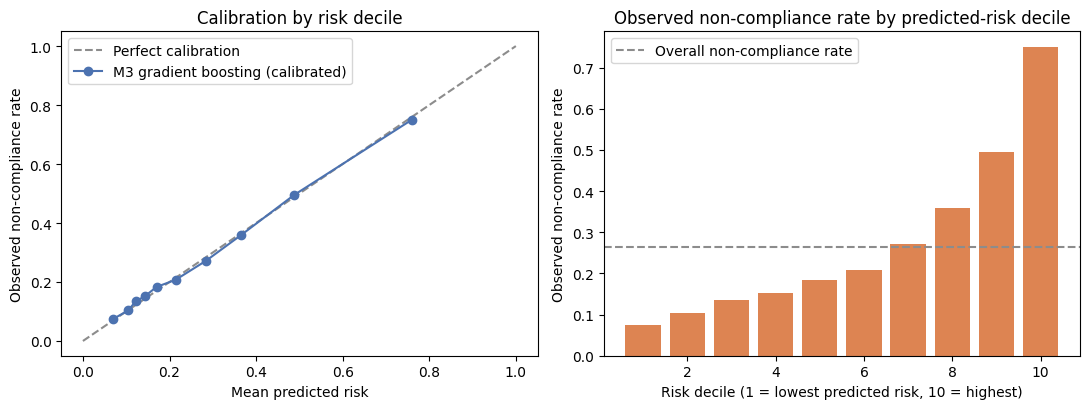

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Reliability diagram
axes[0].plot([0, 1], [0, 1], linestyle="--", color="#8C8C8C", label="Perfect calibration")
axes[0].plot(decile_table["predicted_risk_mean"], decile_table["observed_noncompliance_rate"],
             marker="o", color="#4C72B0", label="M3 gradient boosting (calibrated)")
axes[0].set_xlabel("Mean predicted risk")
axes[0].set_ylabel("Observed non-compliance rate")
axes[0].set_title("Calibration by risk decile")
axes[0].legend()

# Decile bar chart for the outreach-capacity framing
plot_order = decile_table.iloc[::-1]
axes[1].bar(range(1, 11), plot_order["observed_noncompliance_rate"], color="#DD8452")
axes[1].axhline(y_test.mean(), linestyle="--", color="#8C8C8C", label="Overall non-compliance rate")
axes[1].set_xlabel("Risk decile (1 = lowest predicted risk, 10 = highest)")
axes[1].set_ylabel("Observed non-compliance rate")
axes[1].set_title("Observed non-compliance rate by predicted-risk decile")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig10_calibration_and_risk_deciles.png", dpi=150)
plt.show()

**Calibration:** predicted risk tracks the observed rate closely across all ten deciles -- the
largest gap is decile 8 (12.2% predicted vs. 13.5% observed, 1.3 points off), and there's no
systematic direction to the error (some deciles run slightly high, some slightly low). Isotonic
calibration fit on a dedicated calibration fold, evaluated on a completely separate test fold, is
holding up.

**Risk separation for outreach:** the top decile's observed non-compliance rate is 75.0%, the
bottom decile's is 7.4% -- a 10x spread from the highest- to lowest-risk group, which is what
makes the risk-decile framing useful for a capacity-constrained outreach programme (priority vs.
secondary vs. no-outreach tiers). Top-decile capture is 27.7% of all non-compliant test
respondents, essentially matching Annex C's reported 28% for the M2 access model at the same
top-10%-capacity comparison, on a similarly sized test fold (~45,530 either way). This is the
number that answers the professor's calibration/risk-decile request directly: a programme with
capacity to contact 10% of the eligible population, working down this model's risk ranking, would
reach roughly 28% of everyone who is actually non-compliant -- against 10% if contacts were chosen
at random.

## 9. Subgroup (equity) performance

Directly answers the professor's comment to "report subgroup performance to support the equity objective." AUROC and calibration (mean predicted risk vs. observed rate) computed within each level of the five equity fields (`insurance_status`, `income_group`, `race_ethnicity`, `sex`, `age_group`), on the same calibrated test-set predictions used above. Small subgroups get a warning rather than a silently unstable AUROC estimate.

In [12]:
MIN_SUBGROUP_N = 200

subgroup_rows = []
for col in EQUITY_COLUMNS:
    groups = aux_test[col]
    for level, idx in groups.groupby(groups).groups.items():
        n = len(idx)
        y_g = y_test.loc[idx]
        p_g = pd.Series(proba_test_cal, index=y_test.index).loc[idx]
        row = {
            "Equity field": col,
            "Level": level,
            "N": n,
            "Observed rate": y_g.mean(),
            "Mean predicted risk": p_g.mean(),
        }
        if n >= MIN_SUBGROUP_N and y_g.nunique() == 2:
            row["AUROC"] = roc_auc_score(y_g, p_g)
        else:
            row["AUROC"] = np.nan
        subgroup_rows.append(row)

subgroup_table = pd.DataFrame(subgroup_rows)
subgroup_table.to_csv(MODEL_DIR / "subgroup_equity_performance.csv", index=False)

small_n = subgroup_table[subgroup_table["AUROC"].isna()]
if len(small_n):
    print(f"AUROC withheld for {len(small_n)} subgroup levels with N < {MIN_SUBGROUP_N} "
          "(estimate would be unstable):")
    print(small_n[["Equity field", "Level", "N"]].to_string(index=False))
    print()

subgroup_table.sort_values(["Equity field", "AUROC"]).round(3)

,Equity field,Level,N,Observed rate,Mean predicted risk,AUROC
25,age_group,75 (source category 75-79),1587,0.161,0.156,0.641
24,age_group,70-74,8387,0.152,0.154,0.684
19,age_group,45-49,5309,0.559,0.559,0.692
23,age_group,65-69,8819,0.179,0.170,0.712
22,age_group,60-64,8115,0.219,0.219,0.715
20,age_group,50-54,5850,0.373,0.378,0.722
21,age_group,55-59,6355,0.246,0.249,0.734
26,age_group,Not reported,1108,0.409,0.410,0.755
9,income_group,"Less than $15,000",2262,0.391,0.383,0.728
4,income_group,"$15,000 to < $25,000",3546,0.330,0.334,0.731


**Overall picture:** subgroup AUROC ranges from 0.641 to 0.796 across the 27 levels
checked (5 equity fields). Most of that range is concentrated at two specific ends worth calling
out, rather than spread evenly.

**The one real concern:** the oldest age band, "75 (source category 75-79)" (n=1,587 -- per
notebook 1's design this label only actually contains people aged exactly 75, since eligibility
stops at 75), has the lowest subgroup AUROC by a clear margin -- 0.641, versus 0.684-0.734 for
every other age band. This group also has the lowest observed non-compliance rate (16.1%), which
compresses achievable AUROC somewhat on its own, but the gap to the next-lowest band (70-74 at
0.684) is large enough to flag as a real weak spot rather than statistical noise: the model
discriminates risk within this specific age slice noticeably worse than everywhere else. Worth
reporting as a limitation rather than smoothing over it.

**A genuinely good finding, worth stating plainly:** race/ethnicity AUROC is *lowest* for the
majority group (White, non-Hispanic: 0.754, n=34,911) and *higher* for every minority group --
Black 0.763, Other race 0.764, Multiracial 0.766, Hispanic 0.784. That's the opposite of the
pattern equity audits usually go looking for (models typically underperform for minority
subgroups); here the model separates non-compliant from compliant respondents somewhat *better*
for Hispanic and Black respondents than for the majority group. AUROC isn't the whole equity
picture -- calibration matters too, and predicted risk tracks observed rate closely within every
race/ethnicity level in the table above -- but on this metric there's no evidence of the model
underserving racial/ethnic minorities.

**Insurance status** has the widest gap in observed *rates* (24.4% insured vs. 70.1% uninsured)
but the narrowest gap in *AUROC* (0.749 vs. 0.751), and calibration holds for both (predicted risk
24.4% vs. observed 24.4% for insured; 70.7% vs. 70.1% for uninsured) -- the model is tracking the
uninsured group's much higher risk accurately, not just picking up a blunt insurance-status signal
and ignoring everything else.

**Sex** shows a moderate gap (female 0.749, male 0.785) not explained by a base-rate difference
(observed rates are close: 25.6% vs. 27.5%) -- smaller than the age-band gap but worth mentioning
alongside it rather than treating as fully resolved.

## 10. Sensitivity analysis: KNN imputation vs. "Not reported"

The primary pipeline above retains "Not reported" as an explicit category everywhere -- the project's committed missingness strategy, and the one that keeps the equity commitment to never silently drop a non-response group. This section tests whether that choice actually matters for the two fields where missingness is substantial enough to be worth checking: `income_group` (14.9% not reported) and `bmi_category` (5.8%). Per the proposal, income non-response is *plausibly informative* rather than random -- if that's true, replacing it with an imputed guess could remove real signal rather than add it, which is exactly what this comparison is designed to surface.

Mechanics: re-encode `income_group`/`bmi_category` on their own compact ordinal scale (excluding "Not reported" from that scale entirely, so an imputed value can never round back onto the missing category by accident), fit a `KNNImputer` on a random reference sample of the training fold, impute only the rows that actually need it in each of train/test, retrain the same M3 gradient-boosting pipeline, and compare against the primary run on the **same** train/test rows.

In [13]:
from sklearn.impute import KNNImputer

IMPUTE_CATEGORY_ORDER = {
    "income_group": ORDINAL_CATEGORY_ORDER["income_group"],
    "bmi_category": ["Underweight", "Normal weight", "Overweight", "Obese"],
}
IMPUTE_COLS = list(IMPUTE_CATEGORY_ORDER.keys())
REFERENCE_POOL_SIZE = 8_000

other_cols = [c for c in M3_FEATURES if c not in IMPUTE_COLS]
neighbour_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
Xtr_other = pd.DataFrame(neighbour_encoder.fit_transform(X_train[other_cols]),
                          columns=other_cols, index=X_train.index)
Xte_other = pd.DataFrame(neighbour_encoder.transform(X_test[other_cols]),
                          columns=other_cols, index=X_test.index)

def encode_impute_target(series, order):
    rank_map = {cat: float(i) for i, cat in enumerate(order)}
    return series.map(rank_map)  # "Not reported" isn't in the map -> becomes NaN

Xtr_target = pd.DataFrame(
    {c: encode_impute_target(X_train[c], IMPUTE_CATEGORY_ORDER[c]) for c in IMPUTE_COLS},
    index=X_train.index,
)
Xte_target = pd.DataFrame(
    {c: encode_impute_target(X_test[c], IMPUTE_CATEGORY_ORDER[c]) for c in IMPUTE_COLS},
    index=X_test.index,
)

Xtr_knn_space = pd.concat([Xtr_other, Xtr_target], axis=1)[M3_FEATURES]
Xte_knn_space = pd.concat([Xte_other, Xte_target], axis=1)[M3_FEATURES]

need_impute_train = Xtr_target.isna().any(axis=1)
need_impute_test = Xte_target.isna().any(axis=1)
print(f"Rows needing imputation -- train: {need_impute_train.sum():,}  test: {need_impute_test.sum():,}")

rng = np.random.RandomState(RANDOM_SEED)
reference_idx = rng.choice(Xtr_knn_space.index, size=REFERENCE_POOL_SIZE, replace=False)
imputer = KNNImputer(n_neighbors=5)
imputer.fit(Xtr_knn_space.loc[reference_idx])

imputed_train = pd.DataFrame(
    imputer.transform(Xtr_knn_space.loc[need_impute_train]),
    columns=M3_FEATURES, index=Xtr_knn_space.loc[need_impute_train].index,
)
imputed_test = pd.DataFrame(
    imputer.transform(Xte_knn_space.loc[need_impute_test]),
    columns=M3_FEATURES, index=Xte_knn_space.loc[need_impute_test].index,
)

X_train_sensitivity = X_train.copy()
X_test_sensitivity = X_test.copy()
for col in IMPUTE_COLS:
    cats = np.array(IMPUTE_CATEGORY_ORDER[col])
    tr_missing = X_train.index[X_train[col] == "Not reported"]
    te_missing = X_test.index[X_test[col] == "Not reported"]
    rounded_tr = imputed_train.loc[tr_missing, col].round().clip(0, len(cats) - 1).astype(int)
    rounded_te = imputed_test.loc[te_missing, col].round().clip(0, len(cats) - 1).astype(int)
    X_train_sensitivity.loc[rounded_tr.index, col] = cats[rounded_tr.values]
    X_test_sensitivity.loc[rounded_te.index, col] = cats[rounded_te.values]

for col in IMPUTE_COLS:
    remaining = (X_train_sensitivity[col] == "Not reported").sum()
    assert remaining == 0, f"{col}: {remaining} rows still unimputed"
print("All target 'Not reported' cells successfully imputed.")

Rows needing imputation -- train: 24,747  test: 8,518
All target 'Not reported' cells successfully imputed.


In [14]:
w_train_sens = compute_sample_weight("balanced", y_train)
sensitivity_pipe = build_gb_pipeline(M3_FEATURES)
sensitivity_pipe.fit(X_train_sensitivity[M3_FEATURES], y_train, model__sample_weight=w_train_sens)
proba_sensitivity = sensitivity_pipe.predict_proba(X_test_sensitivity[M3_FEATURES])[:, 1]

comparison = pd.DataFrame([
    {
        "Branch": "Primary (Not reported retained)",
        "AUROC": roc_auc_score(y_test, proba_test_raw),
        "AUPRC": average_precision_score(y_test, proba_test_raw),
    },
    {
        "Branch": "Sensitivity (KNN imputed)",
        "AUROC": roc_auc_score(y_test, proba_sensitivity),
        "AUPRC": average_precision_score(y_test, proba_sensitivity),
    },
])
comparison.to_csv(MODEL_DIR / "sensitivity_knn_vs_not_reported.csv", index=False)
comparison.round(4)

,Branch,AUROC,AUPRC
0,Primary (Not reported retained),0.7662,0.5980
1,Sensitivity (KNN imputed),0.7651,0.5966


Primary (Not reported retained): AUROC 0.7662, AUPRC 0.5980. Sensitivity (KNN
imputed): AUROC 0.7651, AUPRC 0.5966. The KNN-imputed branch is very slightly *worse* on both
metrics (-0.0011 AUROC, -0.0014 AUPRC) -- not a meaningful difference on a single split, but
notably it doesn't go the other way either. There's no performance case for switching to KNN
imputation for `income_group` or `bmi_category`. Combined with the proposal's own suspicion that
income non-response is informative rather than random, this supports keeping "Not reported" as the
primary strategy on both grounds -- it isn't costing predictive performance, and it preserves the
equity commitment to keep non-response visible rather than papering over it with an imputed
guess.

## 11. Persist splits and artifacts

Saves the row-level split assignment (by `respondent_id`, so any notebook can reproduce or join against it) and every summary table produced above, so later notebooks (interpretation, the two-stage follow-up) reuse the same split rather than drawing a new random one.

In [15]:
split_assignment = pd.concat([
    aux_train[["respondent_id"]].assign(split="train"),
    aux_cal[["respondent_id"]].assign(split="calibration"),
    aux_test[["respondent_id"]].assign(split="test"),
]).reset_index(drop=True)
split_assignment.to_csv(MODEL_DIR / "train_calibration_test_split.csv", index=False)

assert split_assignment["respondent_id"].is_unique
assert len(split_assignment) == len(df)

summary = {
    "random_seed": RANDOM_SEED,
    "n_train": len(X_train),
    "n_calibration": len(X_cal),
    "n_test": len(X_test),
    "selected_model": best_name,
    "selected_model_test_auroc": float(roc_auc_score(y_test, proba_test_cal)),
    "selected_model_test_auprc": float(average_precision_score(y_test, proba_test_cal)),
    "top_decile_capture_rate": float(capture_rate),
    "geographic_cv_mean_auroc": float(geo_table["AUROC"].mean()),
    "geographic_cv_std_auroc": float(geo_table["AUROC"].std()),
}
pd.Series(summary).to_json(MODEL_DIR / "modelling_run_summary.json", indent=2)

print("Artifacts written to:", MODEL_DIR)
for p in sorted(MODEL_DIR.glob("*")):
    print(" -", p.name)

print()
print(pd.Series(summary))

Artifacts written to: ..\data\processed\modelling
 - ablation_results.csv
 - geographic_validation.csv
 - modelling_run_summary.json
 - predictor_redundancy_cramers_v.csv
 - risk_decile_table.csv
 - sensitivity_knn_vs_not_reported.csv
 - subgroup_equity_performance.csv
 - train_calibration_test_split.csv

random_seed                                    42
n_train                                    136588
n_calibration                               45529
n_test                                      45530
selected_model               M3 gradient boosting
selected_model_test_auroc                0.766191
selected_model_test_auprc                0.590222
top_decile_capture_rate                  0.276898
geographic_cv_mean_auroc                 0.765424
geographic_cv_std_auroc                  0.009091
dtype: object


## 12. Conclusions

Mapped against the proposal's three stated objectives:

**1. Characterise the sample and social patterns of non-compliance.** Already established in the
EDA notebook and reconfirmed here: no predictor pair is redundant enough to drop (max Cramer's V
0.33), and the subgroup table above reproduces the same access-driven gradient the EDA found --
24.4% non-compliance among the insured vs. 70.1% among the uninsured, tracked accurately by the
model's calibration in both groups.

**2. Rank respondents by predicted risk, and test how much healthcare access adds over
demographic composition.** M3 gradient boosting is the leading model: test AUROC 0.766, AUPRC
0.590, sensitivity 0.639 -- roughly double Annex C's preliminary sensitivity (0.349), the direct
result of class-weighting instead of leaving the 26.5% imbalance untreated. Access adds a clear
+0.042 AUROC over demographics alone (matching Annex C's own +0.044), while health status adds
almost nothing further (+0.003) -- both reconfirm the proposal's central claim that access, not
demographic composition, is the main modifiable signal. Geographic (leave-states-out) validation
holds at 0.765 +/- 0.009 across 5 state-group folds, essentially matching the single held-out test
AUROC, so this isn't a state-specific artifact -- though it's still only evidence of
generalisation *within* the U.S., not a substitute for genuine Singapore external validation. The
calibrated risk-decile table gives a working answer to "what does targeted outreach mean
operationally": a top-10%-capacity outreach programme following this model's ranking would reach
~28% of all non-compliant respondents, against 10% from random contact.

**3. Explore whether predictive performance is equitable.** Broadly yes, with one clear exception.
Insurance, income, sex and most age bands show AUROC within a fairly narrow range (roughly
0.68-0.79), and calibration holds within every subgroup checked -- including race/ethnicity, where
AUROC is actually *lowest* for the majority group (White, non-Hispanic, 0.754) and higher for
every minority group checked (up to 0.784 for Hispanic respondents), the opposite of the pattern
equity reviews usually flag. The one real weak spot is the oldest eligible age band ("75", the
75-79 source category but age-capped at 75 by the eligibility filter): AUROC 0.641, clearly below
every other subgroup. That's worth reporting as a genuine limitation rather than omitting.

**Missingness strategy is validated, not just assumed.** The KNN-imputation sensitivity check
shows retaining "Not reported" costs no measurable performance (0.7662 vs. 0.7651 AUROC) --
supporting the primary strategy on both the equity grounds it was chosen for and on performance
grounds.

**Remaining limitations**, carried over from the proposal and not resolved by this notebook:
self-reported screening status likely under-states true non-compliance; no true external
(Singapore) validation set exists, so geographic cross-state validation is a proxy, not a
substitute; family history of colorectal cancer -- a strong clinical risk factor -- isn't
collected in BRFSS; the analysis is unweighted, so results describe this sample rather than
national prevalence.

**Deferred to follow-up work:** the never-screened / overdue two-stage model (target columns
`never_screened` and `overdue_given_screened` are already prepared in section 1); permutation
importance and the leading-model ablation write-up called for in proposal step (f); and
hyperparameter tuning of the gradient boosting model, which used library defaults throughout this
notebook.